# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Redmar van Sinderen
* Username: risinderen
* Student number: S6446248
* Group (AS1, etc.): As 1

-----

In [ ]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

/tmp/ipykernel_869819/33375224.py:11: RuntimeWarning: divide by zero encountered in divide
  v = ((G*M)/radius)**0.5


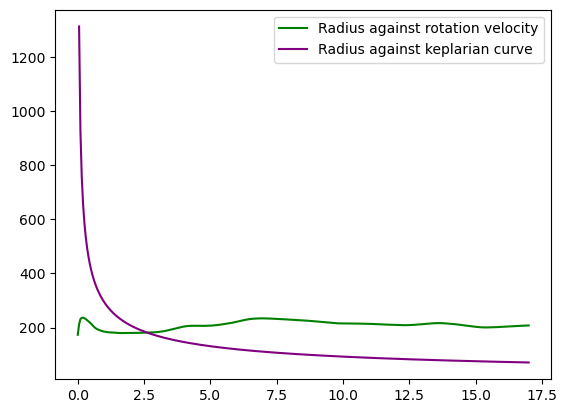

Personally i dont see a correlation between the two curves


In [15]:
import numpy as np
import matplotlib.pyplot as plt

G = 4.301e-6  #units: kpc M^-1 (km/s)^2 
M = 2e10
data = np.loadtxt("RandV.txt")

radius = data[:,0]        #radius in kpc
rotation_vel = data[:,1]       #rotation velocity in km/s

v = ((G*M)/radius)**0.5

np.savetxt("keplerian_curve.txt", v)       #Saves the data of v (the speed) as a txt file under the name of keplerian_curve
kep_curve = np.loadtxt("keplerian_curve.txt")        #Loads said file back into the jnotebook


plt.plot(radius, rotation_vel, color='g', label="Radius against rotation velocity")
plt.plot(radius, kep_curve, color='purple', label = "Radius against keplarian curve")
plt.legend()
plt.show()
print("Personally i dont see a correlation between the two curves" )

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

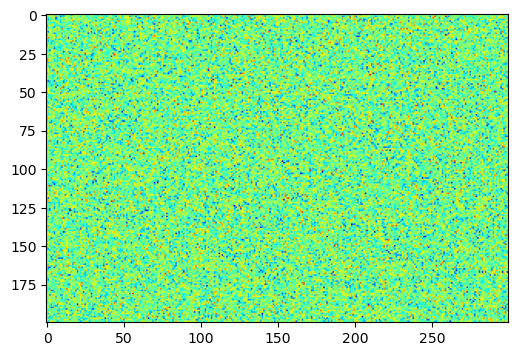

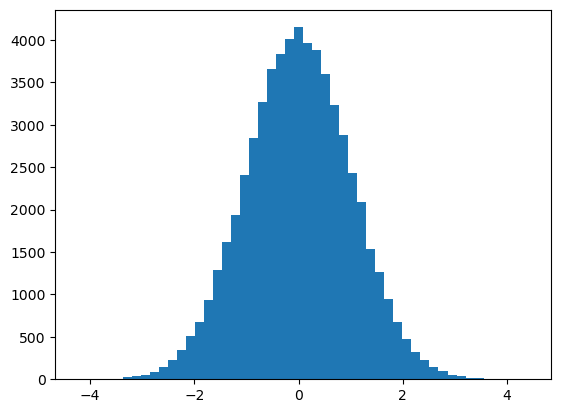

The histogram represents a gaussian distribution


In [48]:
import numpy as np
import matplotlib.pyplot as plt

array = np.random.normal(0,1,60000).reshape(200,300)      #the random distribution of 60000 values in a 200x300 matrix


#the map plot
plt.figure(figsize=(8,4))       #sets the size to 8 inches by 4 inches
plt.imshow(array, cmap='jet')
plt.show()

tbt = array[np.random.choice(array.shape[0], 2, replace=False), :]       #im trying to slice the array here but its not really working lol
#print(tbt)

#the histogram
array_reshape = array.reshape(-1)       #brings the array back to a 1d array
plt.hist(array_reshape, 50)        #the histogram with the data points of the 1d array and 50 bins
plt.show()
print("The histogram represents a gaussian distribution")

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

The area of the elipse with semi major axis of 3 and semi minor axis of 2 is: 18.85
The perimiter of the elipse with semi major axis of 3 and semi minor axis of 2 is roughly: 15.87
The center of the ellipse is: (0, 0) 
The semi major axis is: 3 
The semi minor axis is: 2
10
4
23


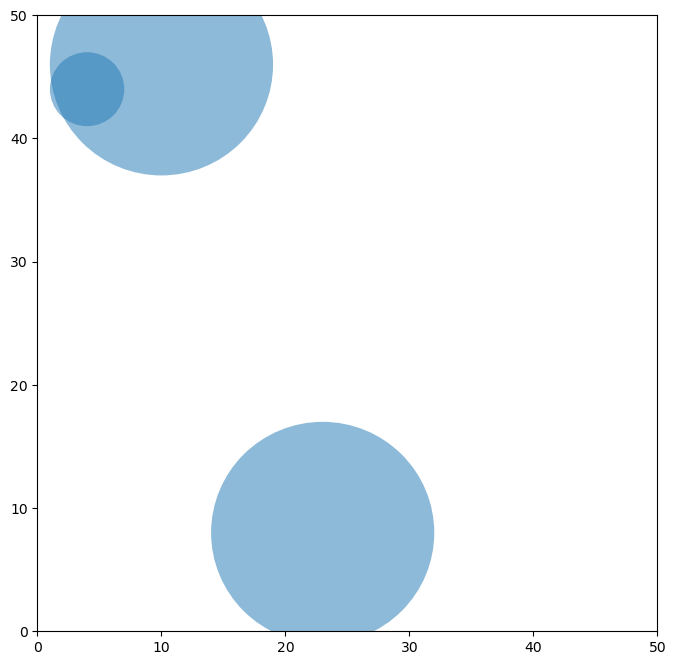

In [1]:
from matplotlib.patches import Ellipse
import numpy as np
from matplotlib.pyplot import show, figure

class AstroEllipse(Ellipse):
   def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
      # We use the (sort of) astronomical angle where 'angle' defines)
      # the position angle of the major axis of a ring projected onto the sky
      # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
      # the north direction on the sky and the major axis of the receding half of the
      # galaxy (Rots 1975, astron, astrophys 45, 43).
      # Here we assume (!) north is in the positive Y direction.
      # If not, you need to correct the angle for the rotation of the image.
      # Parameter 'position_angle' enters in degrees
      assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous
      XY = (xc, yc)                  # MPL requires center as a tuple
      angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
      height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
      width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
      super().__init__(XY, width, height, angle=angle_mpl, **args)
      #these two lines are needed so that semi_major and semi_minor can be used everywhere in the class, otherwise they wont be defined for some reason because just putting in semi_major and semi_minor was not working in the function of area
      self.semi_major = semi_major        
      self.semi_minor = semi_minor
      self.XY = XY
   
   def area(self):
       a = self.semi_major * self.semi_minor * np.pi
       return a
   def perimiter(self):
       P = np.pi*(3*(self.semi_major+self.semi_minor)-((3*self.semi_major+self.semi_minor)*(self.semi_major+3*self.semi_minor))**0.5)
       return P
   def __str__(self):
       return (f"The center of the ellipse is: {self.XY} \nThe semi major axis is: {self.semi_major} \nThe semi minor axis is: {self.semi_minor}")
    
class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, color=('r','g', 'b'), **args):
        super().__init__(xc,yc, semi_major = radius, semi_minor = radius, position_angle = 0, alpha=0.5)      #I dont know what the super here is supposed to mean
        self.radius = radius

        
elip = AstroEllipse(0,0,3,2,90)       #defining set of values for the ellipse.

print(f"The area of the elipse with semi major axis of 3 and semi minor axis of 2 is: {elip.area():.4}")
print(f"The perimiter of the elipse with semi major axis of 3 and semi minor axis of 2 is roughly: {elip.perimiter():.4}")
print(elip.__str__())



fig = figure(figsize=(8,8))
frame = fig.add_subplot(1,1,1)
for i in [1,2,3]:
    xcenter = np.random.randint(0,50)
    print(xcenter)
    ycenter = np.random.randint(0,50)
    r = np.random.randint(0,10)
    circle = MyCircle(xcenter, ycenter, r, color = i )
    frame.add_patch(circle)

frame.set_xlim(0, 50)
frame.set_ylim(0,50)
show()

In [24]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

NameError: name 'totalpoints' is not defined

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

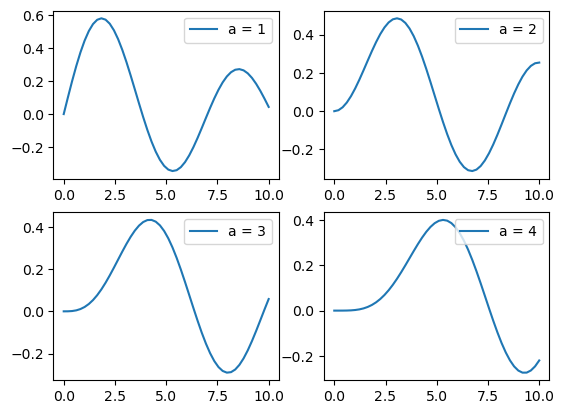

<Figure size 640x480 with 0 Axes>

In [19]:
from scipy.special import jv
import numpy as np
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt

x = np.linspace(0,10)        #x coordinates
fig = figure()
for a in [1,2,3,4]:       #looping over the different a values
    bessel = jv(a,x)        #calculating the bessel funcion
    frame = fig.add_subplot(2,2,a)        #making a 2x2 subplot and making the position equal to which value we are looping over
    frame.plot(x,bessel, label=f"a = {a}")        #plotting the bessel function
    plt.legend(loc='upper right')        #setting the legend to be in the upper right corner
plt.show()

plt.savefig("bessel.png", dpi=100, transparent=True)

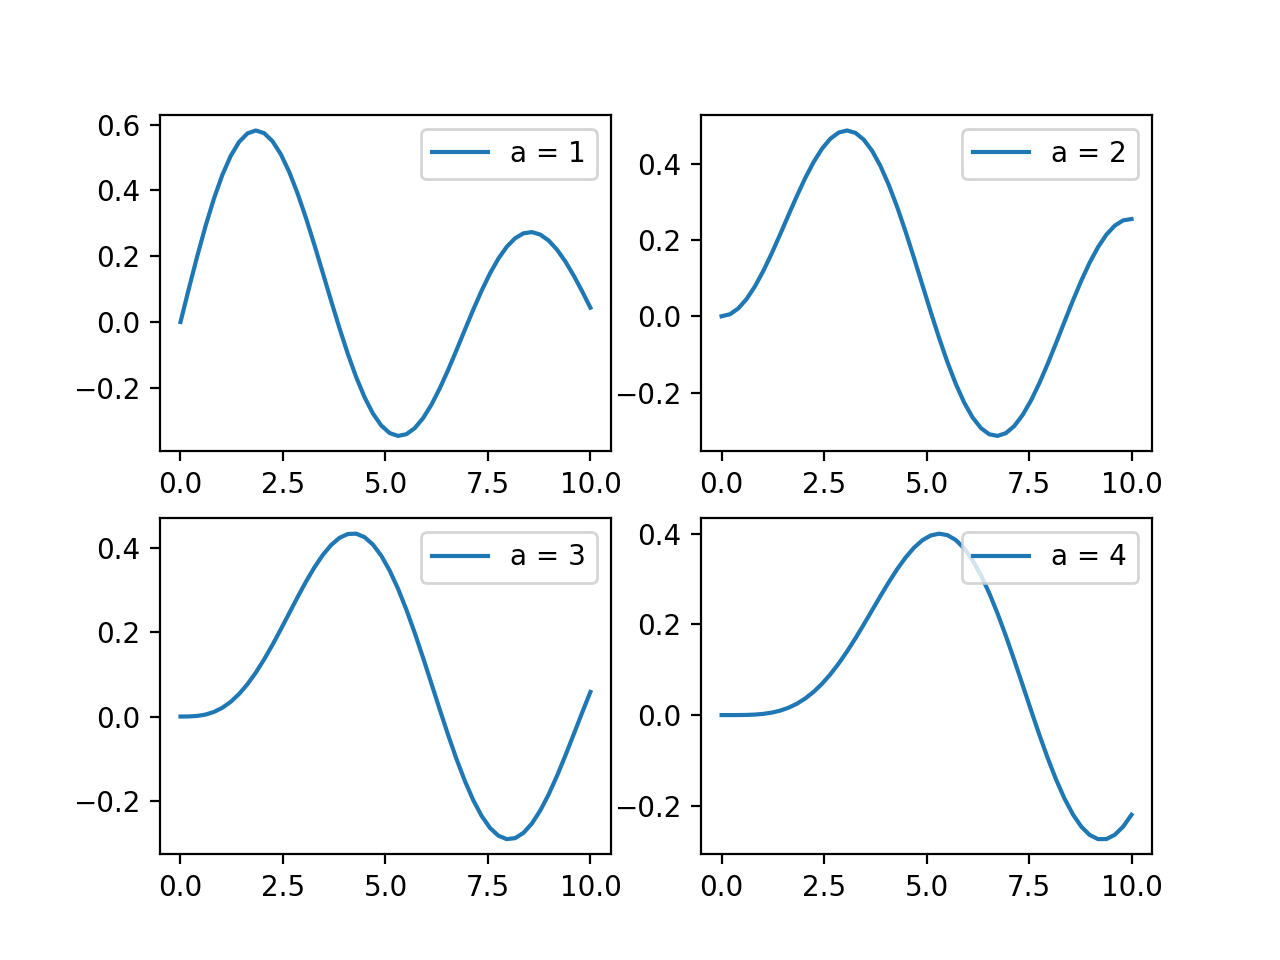

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

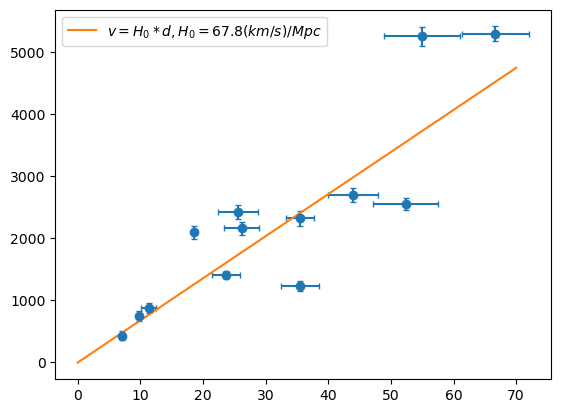

In [16]:
import numpy as np
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt


"""
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
"""
data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]

d = data[0::4]       
v = data[1::4]
errord = data[2::4]
errorv = data[3::4]

d_axis = np.linspace(0,70,100)
chi = d_axis*67.8        #calulating the fit

fig, ax = plt.subplots()
ax.errorbar(d,v,yerr=errorv,xerr=errord, fmt='o', capsize=2)
ax.plot(d_axis,chi, label =r'$v = H_0*d, H_0 = 67.8 (km/s)/Mpc$')
plt.legend()
show()

In [19]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

NameError: name 'totalpoints' is not defined

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")